In [41]:
import json
import gzip
import pandas as pd
import numpy as np
import os
import glob
import random
from pathlib import Path
import anndata
import scipy.sparse as sp
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, adjusted_rand_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.stats import entropy
import warnings
warnings.filterwarnings('ignore')

In [24]:
def load_paths_dict(paths_dict_file):
    """Load the paths dictionary from the compressed JSON file."""
    with gzip.open(paths_dict_file, 'rt') as f:
        return json.load(f)
def load_latent_z(latent_file_path):
    """
    Load latent Z values from tsv.gz file.
    Returns DataFrame with latent embeddings.
    """
    try:
        Z_df = pd.read_csv(latent_file_path, sep="\t", compression="infer")
        
        # Handle potential index column
        if Z_df.dtypes.iloc[0] == "object":
            Z_df = Z_df.set_index(Z_df.columns[0])
        
        # Select only numeric columns
        Z_df = Z_df.select_dtypes(include=[np.number])
        
        return Z_df
        
    except Exception as e:
        print(f"Error loading latent file {latent_file_path}: {e}")
        return None


In [25]:
base_dir = "/n/fs/ragr-data/users/viola/structuredVAE/data"
paths_dict_file = "/n/fs/ragr-data/users/viola/mouse_dev/scripts/new_c_elegans/paths_dict_tree.json.gz"
path_dict = load_paths_dict(paths_dict_file)

In [26]:
umap_pca_correlations = pd.read_csv("../results/umap_pca_correlations.csv",index_col=0)

In [27]:
umap_pca_correlations

,path_length,n_cells,umap_correlation,umap_p_value,pca_correlation,pca_p_value
path_name,,,,,,
ABalaaa_ABalaaaalal,5,227,0.606637,3.305574e-24,0.566160,1.222005e-20
ABalaa_ABalaaaalal,6,227,0.606637,3.305574e-24,0.566160,1.222005e-20
ABala_ABalaaaalal,7,254,0.815010,1.169769e-61,0.687701,6.555744e-37
ABal_ABalaaaalal,8,254,0.815010,1.169769e-61,0.687701,6.555744e-37
ABalaa_ABalaaaalp,5,208,0.740132,2.360560e-37,0.867681,1.890372e-64
...,...,...,...,...,...,...
P2_Dppppp,8,401,0.837914,5.683213e-107,0.914652,4.892069e-159
P1_Z2,5,486,NaN,NaN,NaN,NaN
P0_Z2,6,486,NaN,NaN,NaN,NaN


In [28]:
gmm_analysis = pd.read_csv("../results/pca_gmm_analysis.csv",index_col=-3)

In [29]:
gmm_analysis

,n_components,n_samples,bic,aic,log_likelihood,perplexity,silhouette_score,calinski_harabasz,davies_bouldin,ari_with_lineage,...,js_divergence,kl_divergence_gmm_to_lineage,kl_divergence_lineage_to_gmm,proportion_correlation,proportion_mae,proportion_rmse,gmm_proportions,lineage_proportions,path_length,model
path_name,,,,,,,,,,,,,,,,,,,,,
ABalppp_ABalpppapav,5,505,2554.616013,2495.472195,-2.443042,1.004849,0.520665,1415.331422,1.408948,0.246329,...,NaN,NaN,NaN,NaN,NaN,NaN,"[0.14805487883181567, 0.011375103108520508, 0....","[nan, nan, nan, nan, nan]",5,PCA
ABprap_ABprapapaa,5,260,1719.098127,1669.248584,-3.156247,1.012213,0.522778,791.360892,0.513973,0.408619,...,NaN,NaN,NaN,NaN,NaN,NaN,"[0.2954124014647755, 0.0473780803268495, 0.196...","[nan, nan, nan, nan, nan]",5,PCA
MS_MSapaaaav,8,687,2570.003142,2465.759454,-1.761106,1.002567,0.578052,5008.072194,0.416321,0.237787,...,0.565152,inf,1.216304,0.136913,0.162051,0.265896,"[0.6263965550497469, 0.0014556040737398206, 0....","[0.0, 0.0, 0.0, 0.02419354838709677, 0.0564516...",8,PCA
ABprpa_ABprpapapaa,6,417,2259.101737,2190.539271,-2.585779,1.006220,0.555177,498.455405,0.528829,0.252402,...,NaN,NaN,NaN,NaN,NaN,NaN,"[0.5110603594411554, 0.0023980815347721877, 0....","[nan, nan, nan, nan, nan, nan]",6,PCA
ABpra_ABpraaapapaa,8,541,3153.883908,3055.135265,-2.781086,1.005154,0.593083,2300.569157,0.435174,0.221882,...,0.751229,inf,2.845060,-0.279391,0.231427,0.309776,"[0.20151851060035958, 0.08075518252058617, 0.5...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.3541666666666...",8,PCA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ABarap_ABarapapaa,5,311,1258.132852,1205.775751,-1.893530,1.006107,0.614846,1450.825317,0.449848,0.618422,...,NaN,NaN,NaN,NaN,NaN,NaN,"[0.5875212173106653, 0.0064308681672025775, 0....","[nan, nan, nan, nan, nan]",5,PCA
ABpl_ABplappapp,7,257,1759.712327,1688.730805,-3.207647,1.012559,0.540900,709.225993,0.489394,0.485781,...,0.805781,inf,4.055727,-0.450878,0.280765,0.413806,"[0.32048540812292287, 0.09452280096071791, 0.0...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0]",7,PCA
ABar_ABarppaappp,8,333,1715.622527,1628.035250,-2.375428,1.007159,0.533220,2371.584562,0.479508,0.365229,...,0.593060,inf,1.389832,0.088479,0.168630,0.209754,"[0.4023377589691867, 0.01756735454748164, 0.11...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.3417721518987342, ...",8,PCA


In [30]:
plot_df = umap_pca_correlations.copy()
plot_df['loglikelihood'] = gmm_analysis["log_likelihood"]
plot_df

,path_length,n_cells,umap_correlation,umap_p_value,pca_correlation,pca_p_value,loglikelihood
path_name,,,,,,,
ABalaaa_ABalaaaalal,5,227,0.606637,3.305574e-24,0.566160,1.222005e-20,-1.515670
ABalaa_ABalaaaalal,6,227,0.606637,3.305574e-24,0.566160,1.222005e-20,-1.606668
ABala_ABalaaaalal,7,254,0.815010,1.169769e-61,0.687701,6.555744e-37,-1.882760
ABal_ABalaaaalal,8,254,0.815010,1.169769e-61,0.687701,6.555744e-37,-1.929321
ABalaa_ABalaaaalp,5,208,0.740132,2.360560e-37,0.867681,1.890372e-64,-2.279563
...,...,...,...,...,...,...,...
P2_Dppppp,8,401,0.837914,5.683213e-107,0.914652,4.892069e-159,-2.633428
P1_Z2,5,486,NaN,NaN,NaN,NaN,-1.781557
P0_Z2,6,486,NaN,NaN,NaN,NaN,-1.764761


Text(0, 0.5, 'log-likelihood of fitting GMM')

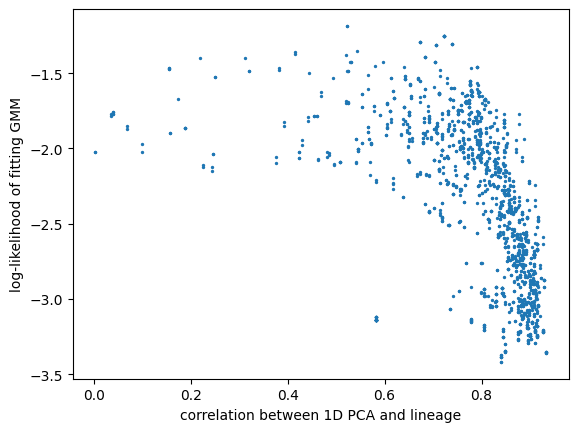

In [32]:

plt.scatter(plot_df["pca_correlation"], plot_df['loglikelihood'], s=2)
plt.xlabel("correlation between 1D PCA and lineage")
plt.ylabel("log-likelihood of fitting GMM")

In [42]:
plt.style.use('default')
sns.set_palette("husl")

In [62]:
def plot_single_path_histogram(path_name, base_dir, method='pca', figsize=(10, 6), bins=50, alpha=0.7):
    """
    Plot histogram for a single path with lineage coloring.
    
    Parameters:
    -----------
    path_name : str
        Name of the path (e.g., 'MS_MSaapapaa')
    base_dir : str
        Base directory containing loom files
    method : str
        Either 'pca' or 'umap'
    figsize : tuple
        Figure size
    bins : int
        Number of histogram bins
    alpha : float
        Transparency for overlapping histograms
    """
    # Load the loom file
    loom_file = os.path.join(base_dir, f"{path_name}.loom")
    
    if not os.path.exists(loom_file):
        print(f"Loom file not found: {loom_file}")
        return None
    
    # Load AnnData
    adata = anndata.read_loom(loom_file)
    
    # Check if coordinates exist
    coord_col = f'{method}_1d'
    if coord_col not in adata.obs.columns:
        print(f"No {method.upper()} coordinates found in {path_name}")
        return None
    
    # Get coordinates and lineage information
    coords = adata.obs[coord_col].values
    lineage_labels = adata.obs['lineage'].values if 'lineage' in adata.obs.columns else None
    
    if lineage_labels is None:
        print(f"No lineage information found for {path_name}")
        return None
    
    # Create figure
    fig, ax = plt.subplots(figsize=figsize)
    
    # Get unique lineage labels and assign colors
    # unique_lineages = sorted(list(set(lineage_labels)))
    unique_items = set(lineage_labels)
    unique_lineages = sorted(unique_items, key=lambda s: len(s.split('/')[0]))

    colors = plt.cm.Set3(np.linspace(0, 1, len(unique_lineages)))
    
    # Plot histograms for each lineage
    for i, lineage in enumerate(unique_lineages):
        lineage_coords = coords[lineage_labels == lineage]
        if len(lineage_coords) > 0:
            ax.hist(lineage_coords, bins=bins, alpha=alpha, 
                   label=lineage, color=colors[i], density=True)
    
    ax.set_title(f'{method.upper()} Coordinates Distribution by Lineage - {path_name}')
    ax.set_xlabel(f'{method.upper()} Coordinate')
    ax.set_ylabel('Normalized Frequency')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(True, alpha=0.3)
    plt.show()
    # plt.tight_layout()
    return fig
def plot_multiple_paths_histograms(base_dir, path_names, method='pca', n_cols=5, figsize=(20, 16)):
    """
    Plot histograms for multiple paths in a grid layout.
    
    Parameters:
    -----------
    base_dir : str
        Base directory containing loom files
    path_names : list
        List of path names to visualize
    method : str
        Either 'pca' or 'umap'
    n_cols : int
        Number of columns in the grid
    figsize : tuple
        Figure size
    """
    for path in path_names:
        plot_single_path_histogram(path,base_dir)

In [56]:
def get_random_paths(base_dir, path_dict, n_paths=50, seed=42):
    """
    Get random path names from loom files.
    
    Parameters:
    -----------
    base_dir : str
        Base directory containing loom files
    n_paths : int
        Number of random paths to select
    seed : int
        Random seed for reproducibility
    
    Returns:
    --------
    list
        List of random path names
    """
    # Find all loom files
    loom_files = glob.glob(os.path.join(base_dir, "*.loom"))
    # path_names = [os.path.basename(f).replace('.loom', '') for f in loom_files]
    path_names = sorted(path_dict.keys())
    print(f"Found {len(path_names)} loom files")
    
    # Randomly select paths
    random.seed(seed)
    if len(path_names) > n_paths:
        selected_paths = random.sample(path_names, n_paths)
    else:
        selected_paths = path_names
        n_paths = len(selected_paths)
    
    print(f"Selected {len(selected_paths)} paths")
    return selected_paths

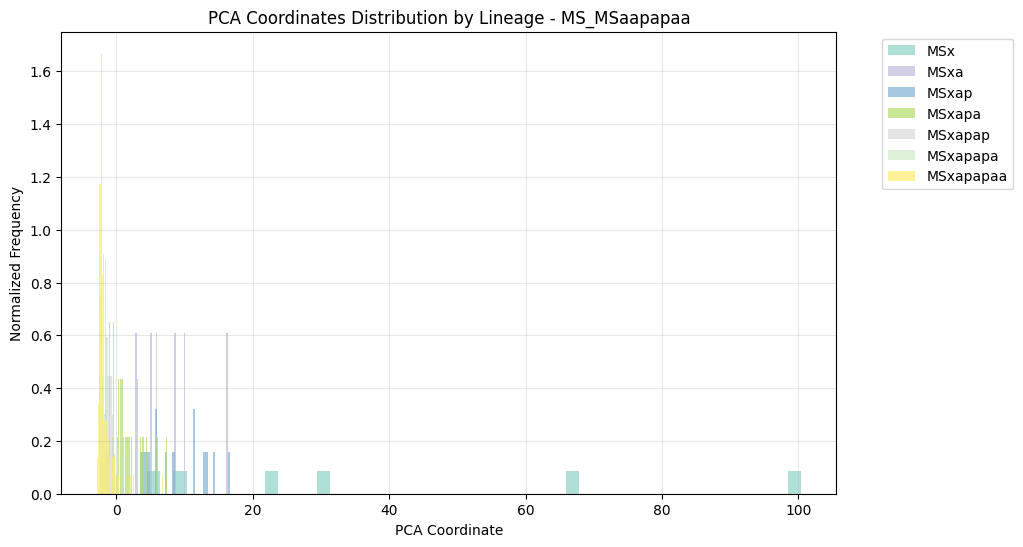

Found 1828 loom files
Selected 25 paths


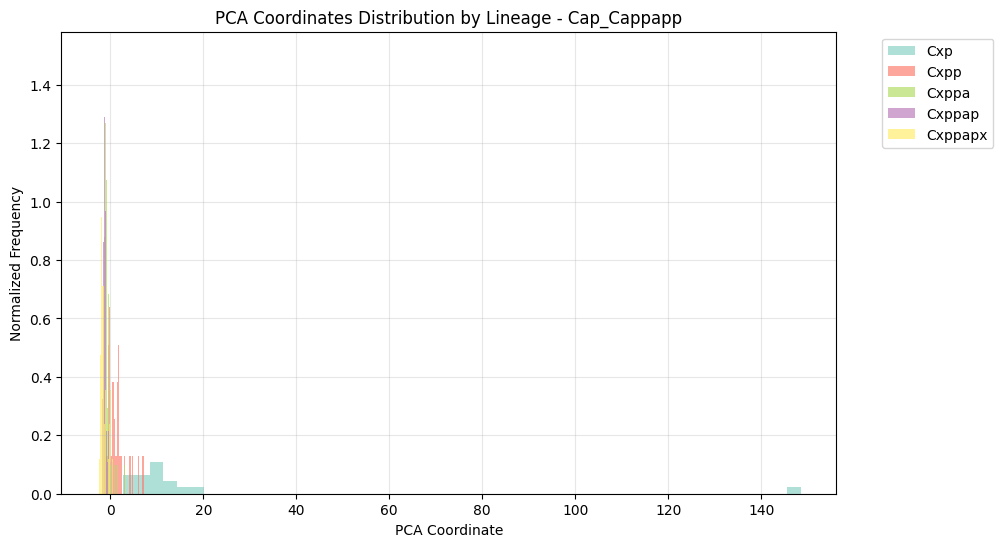

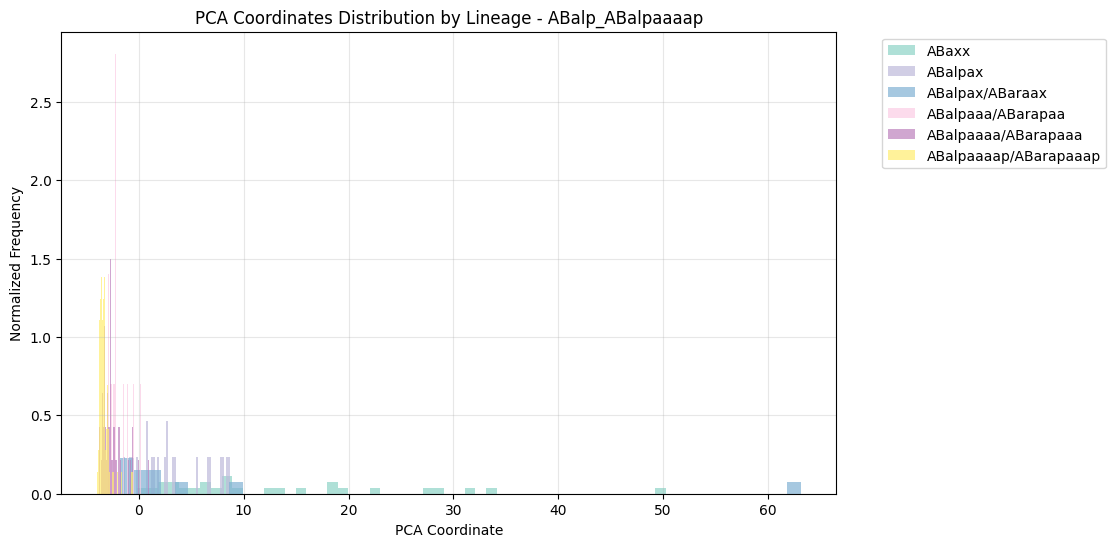

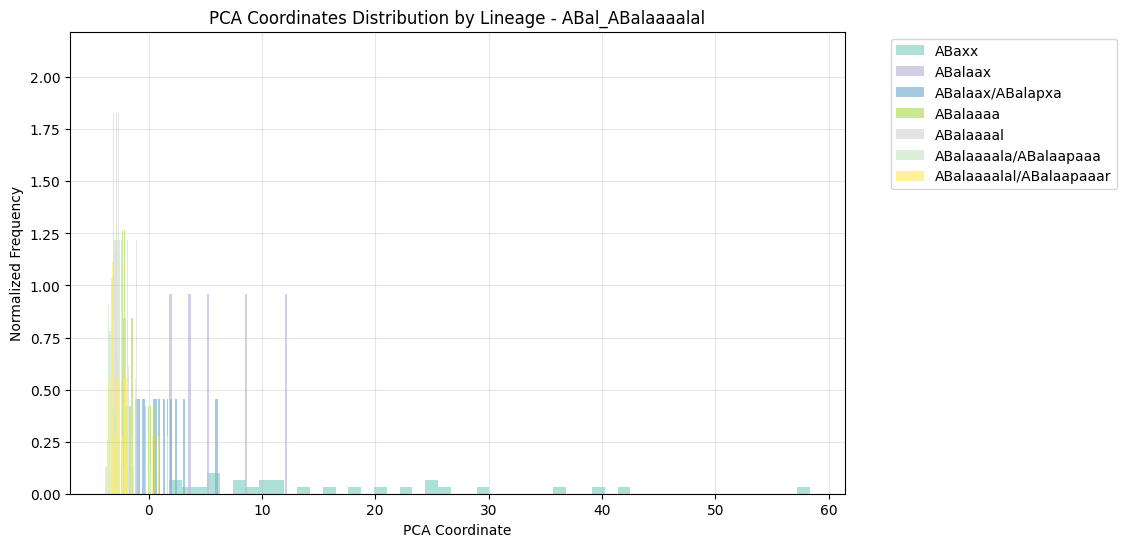

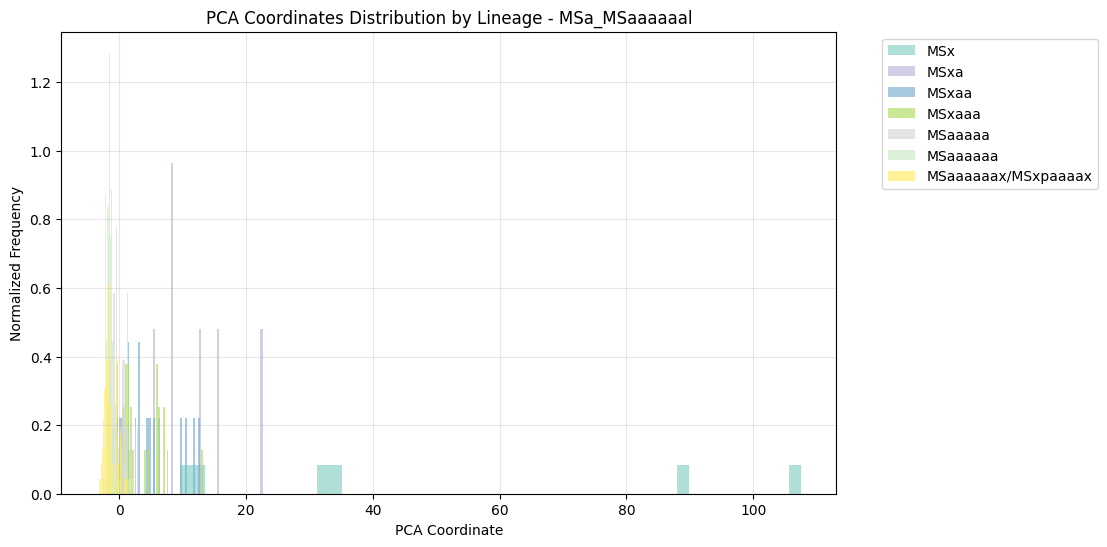

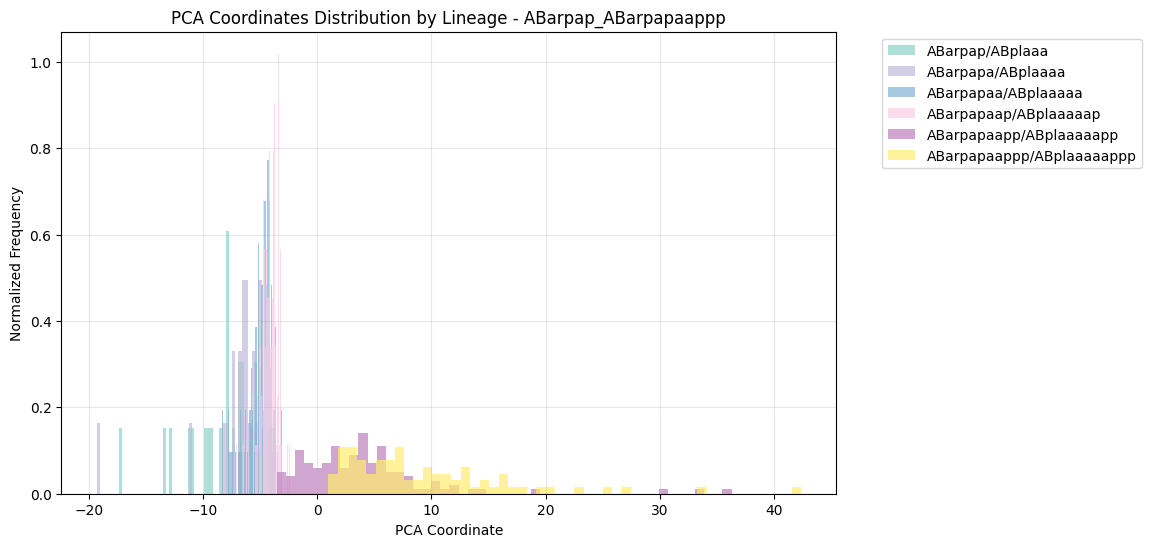

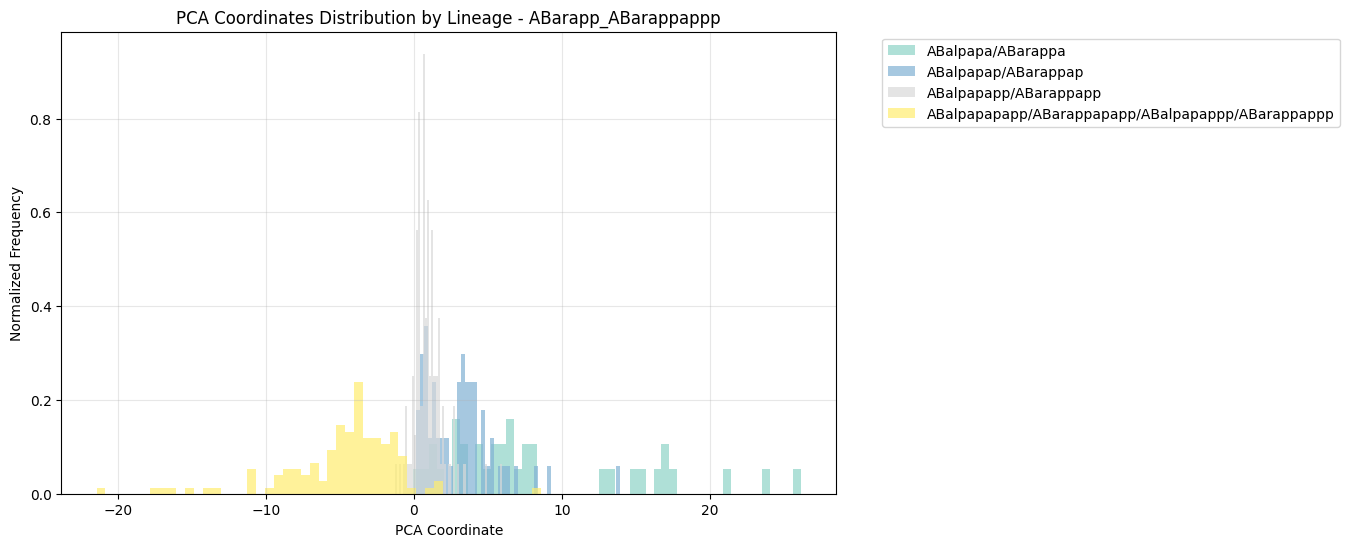

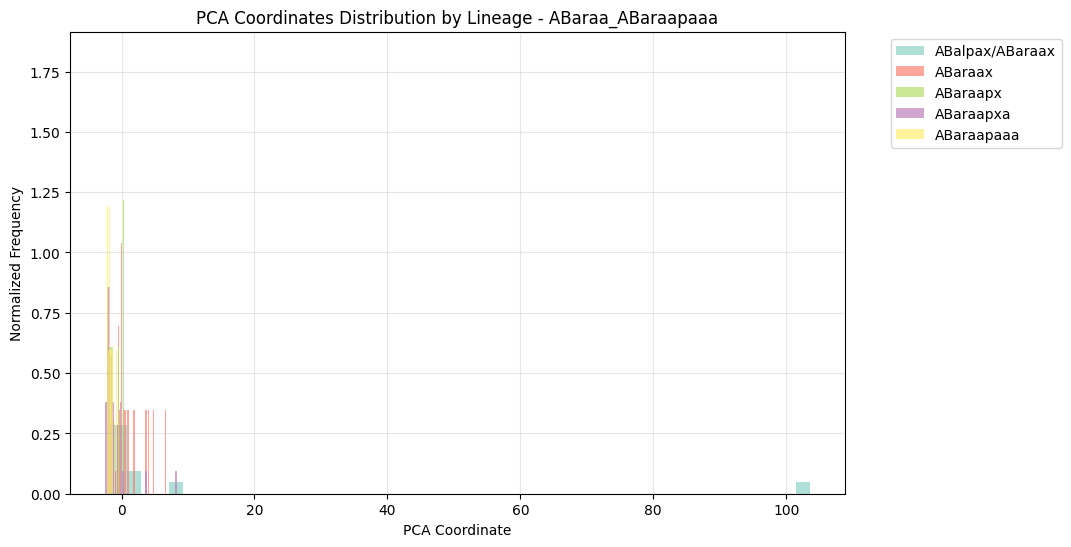

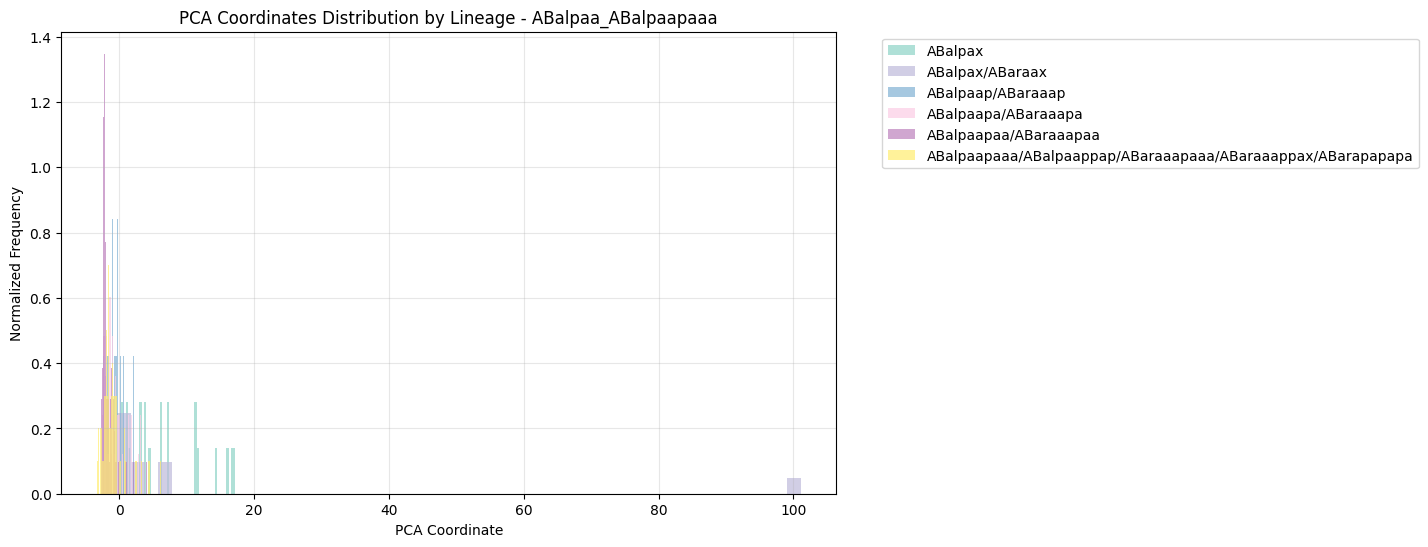

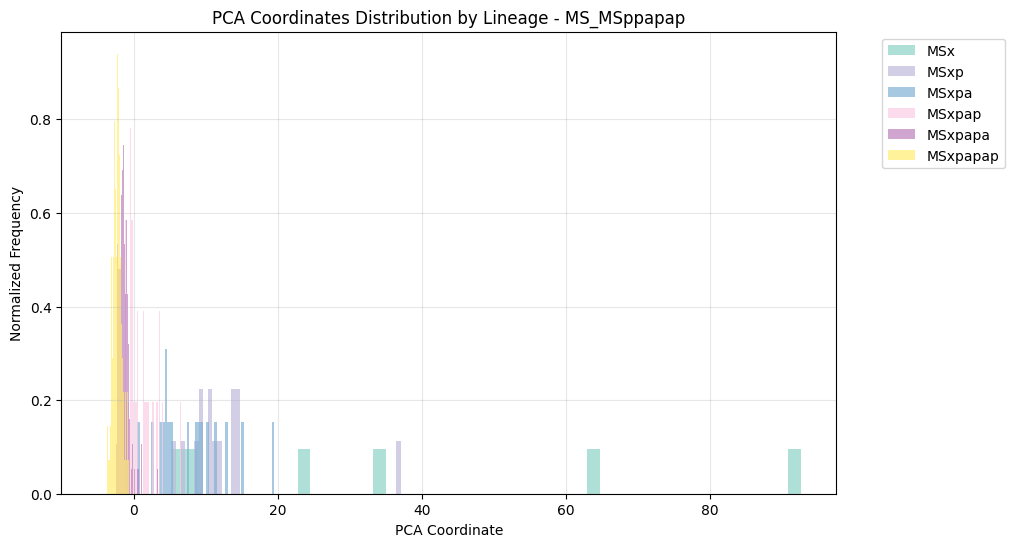

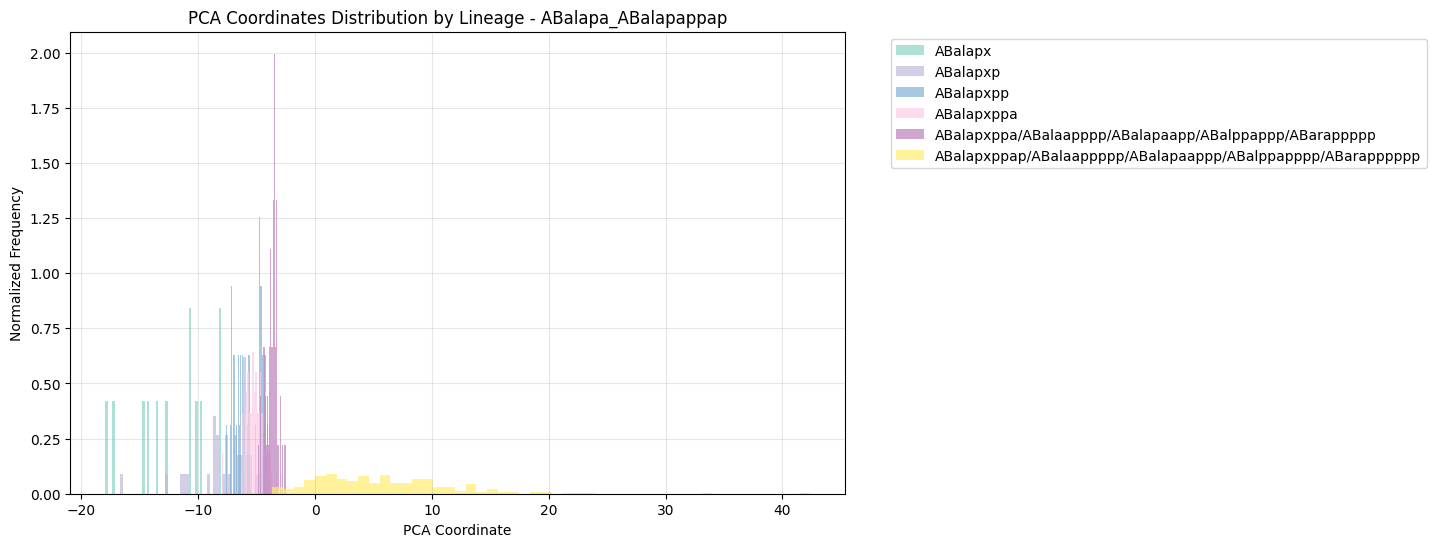

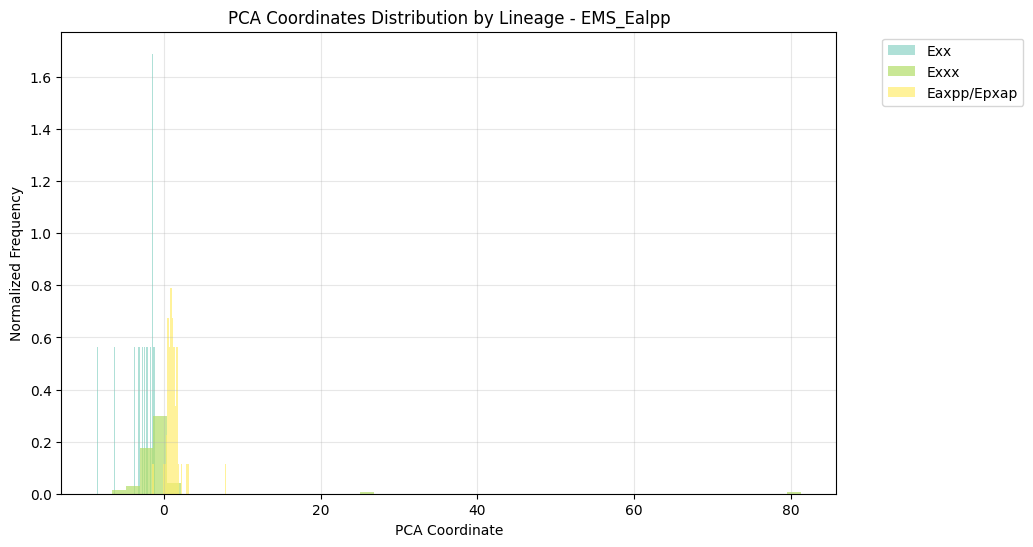

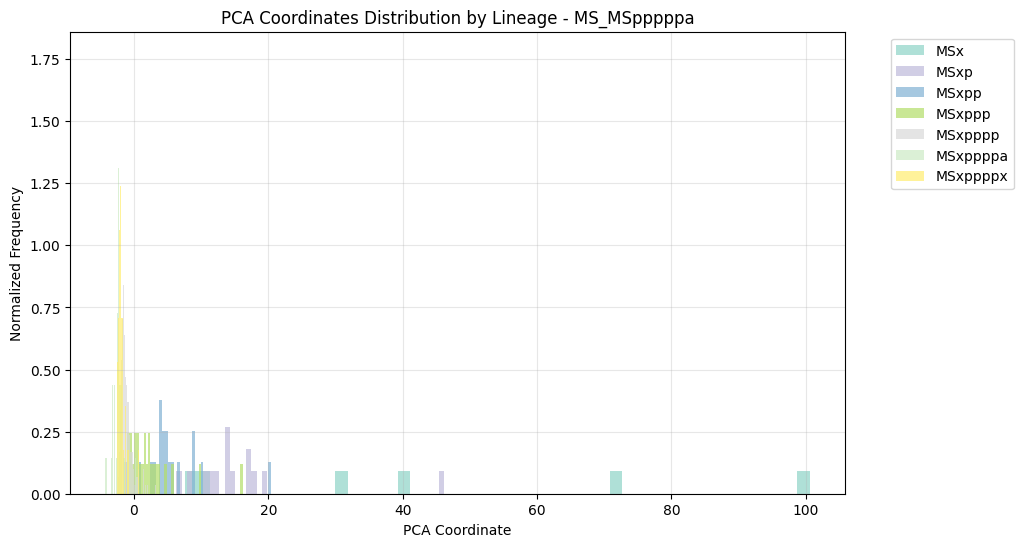

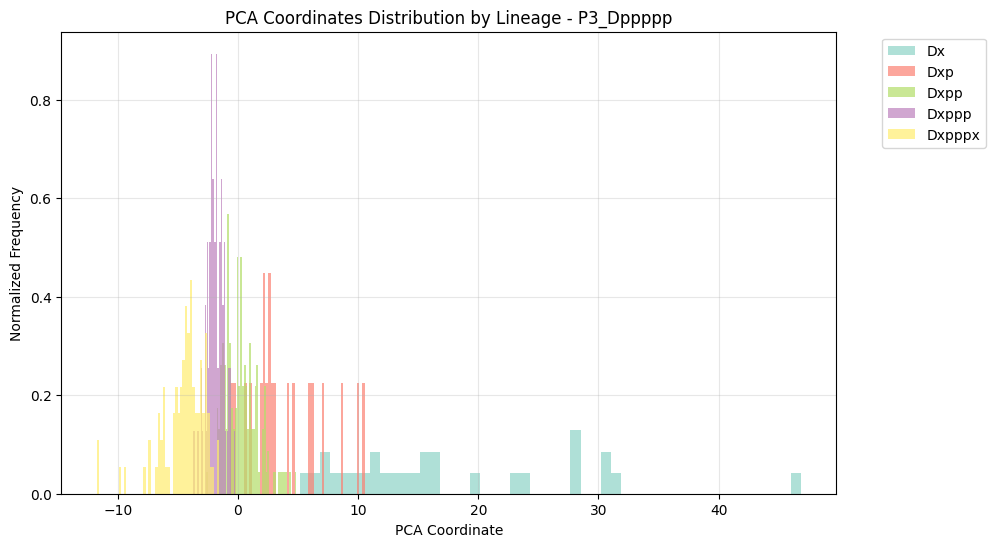

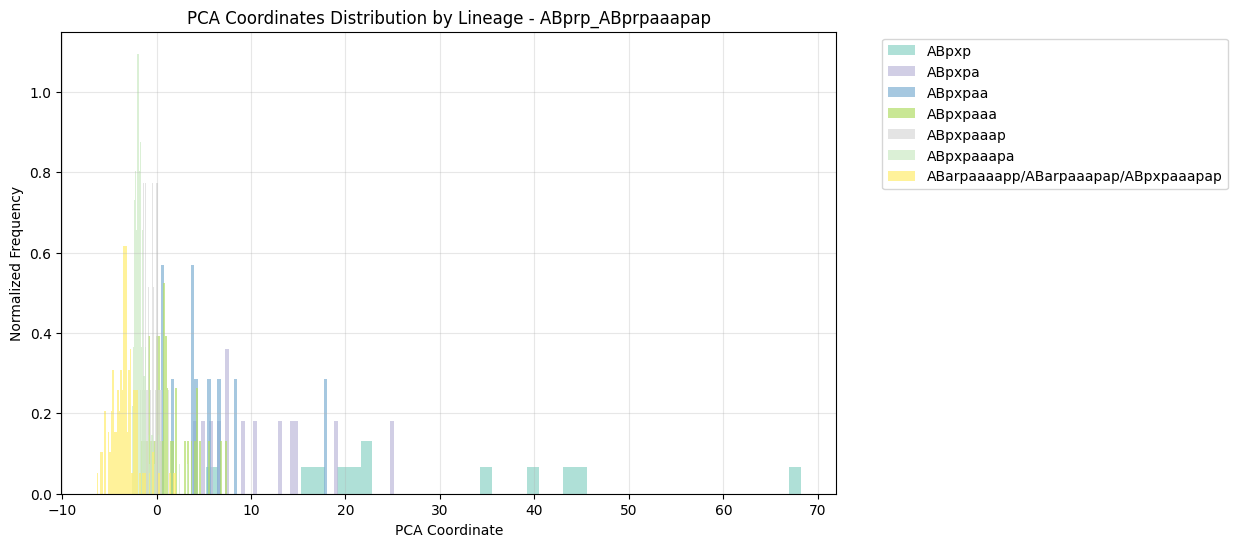

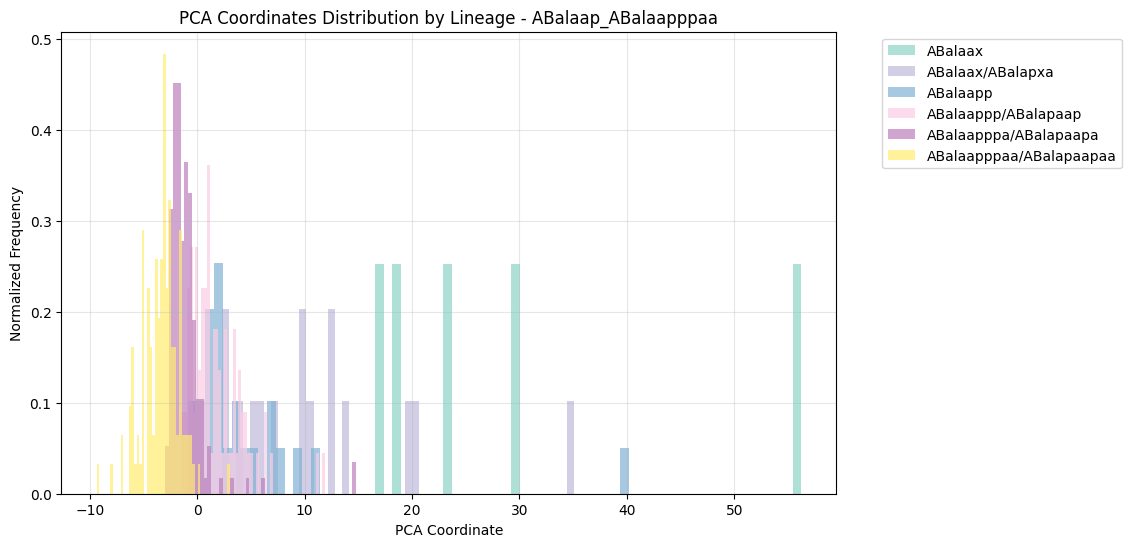

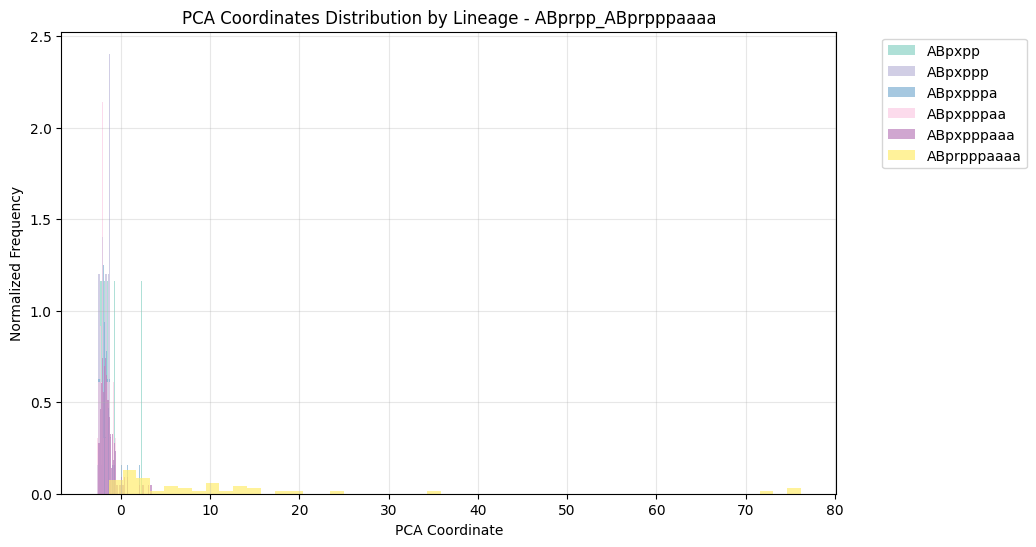

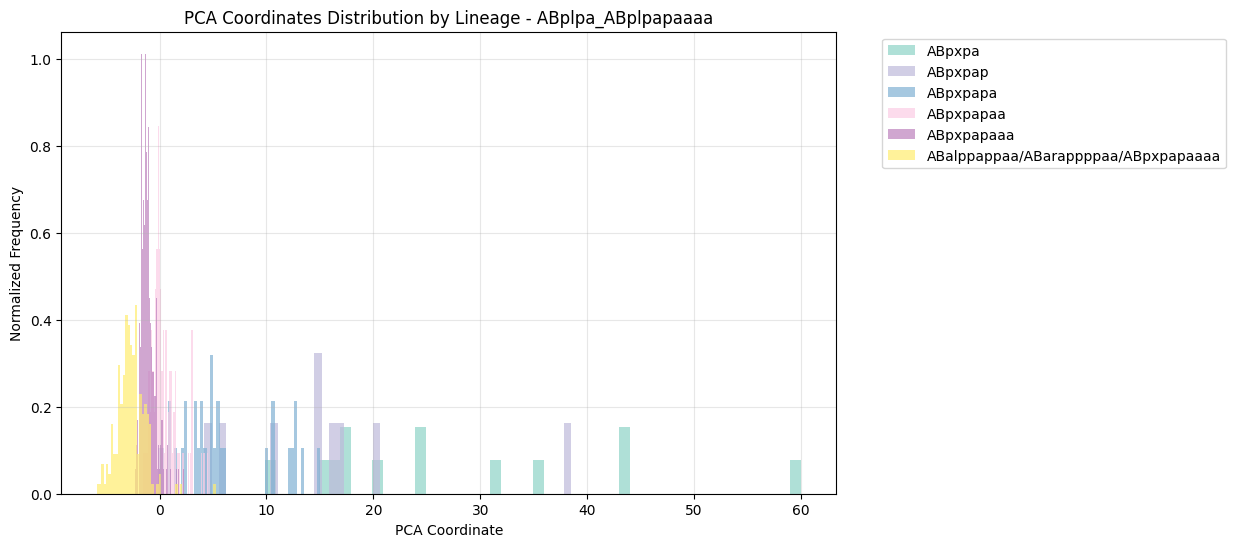

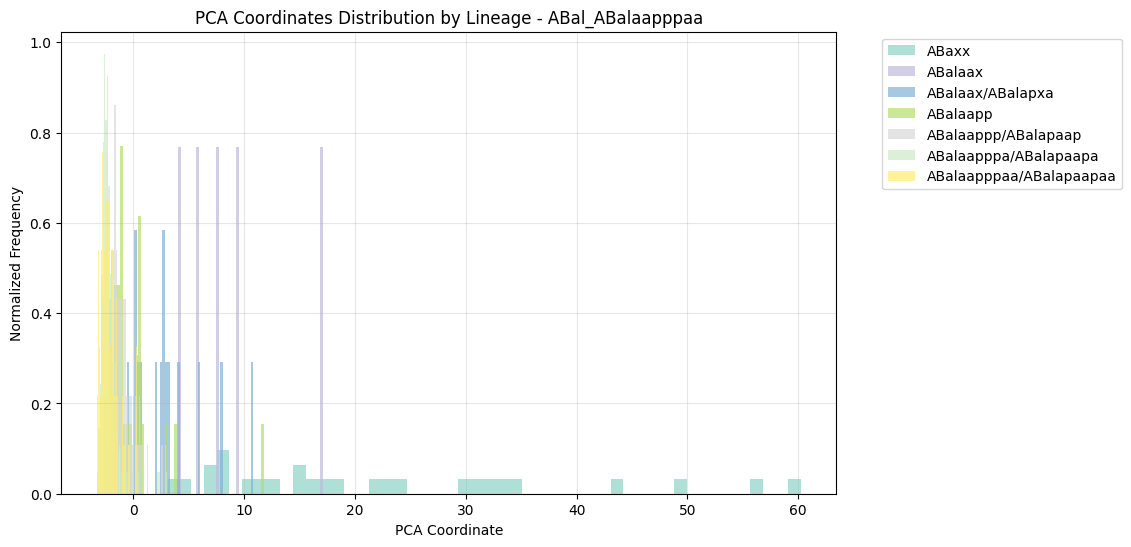

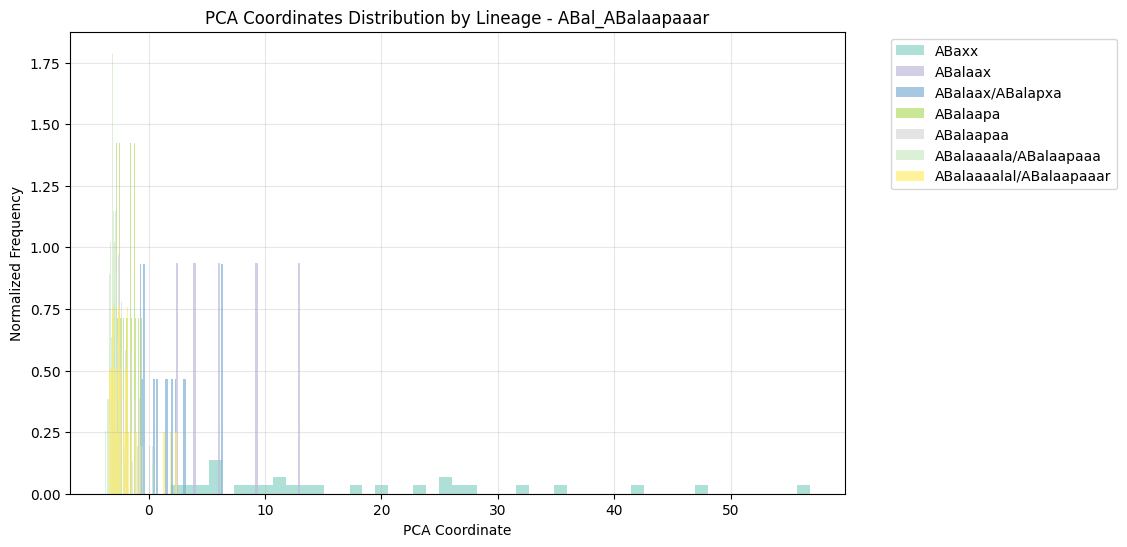

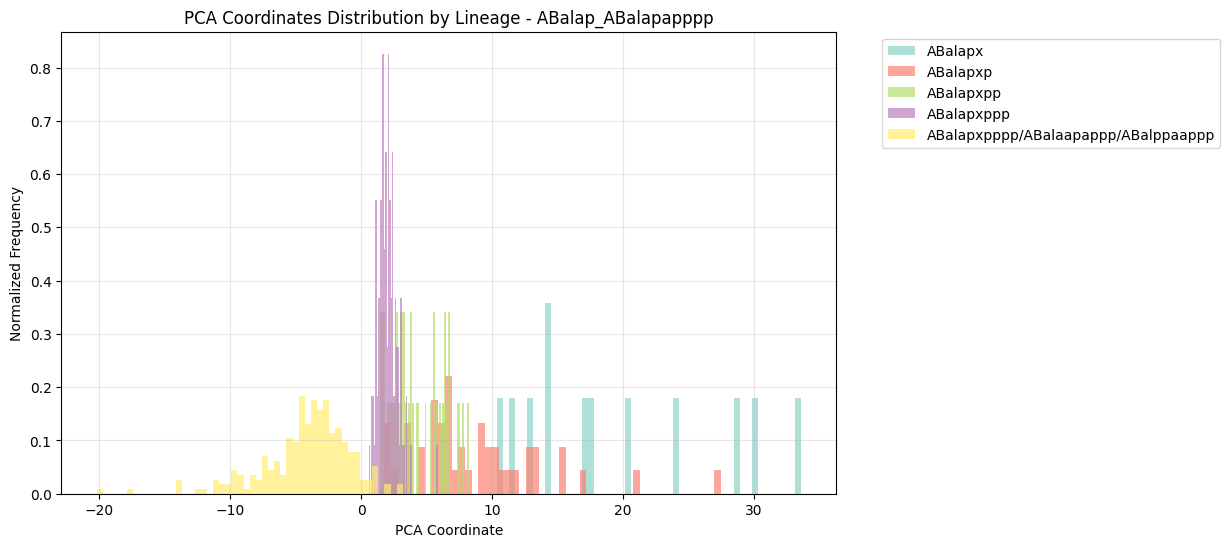

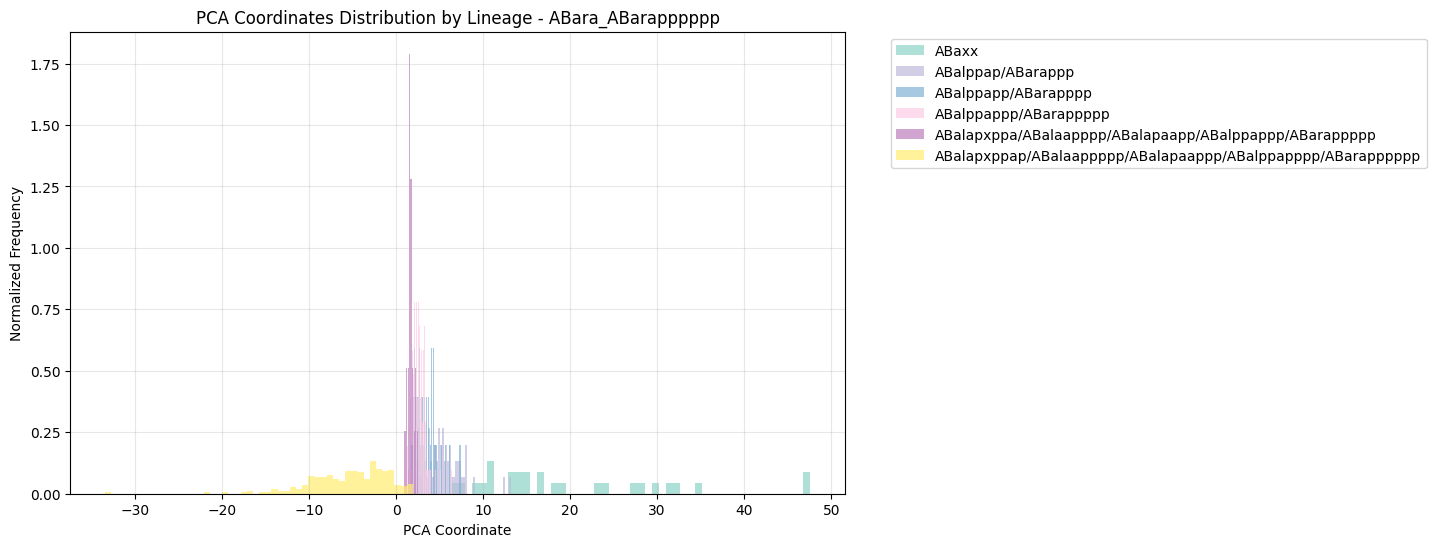

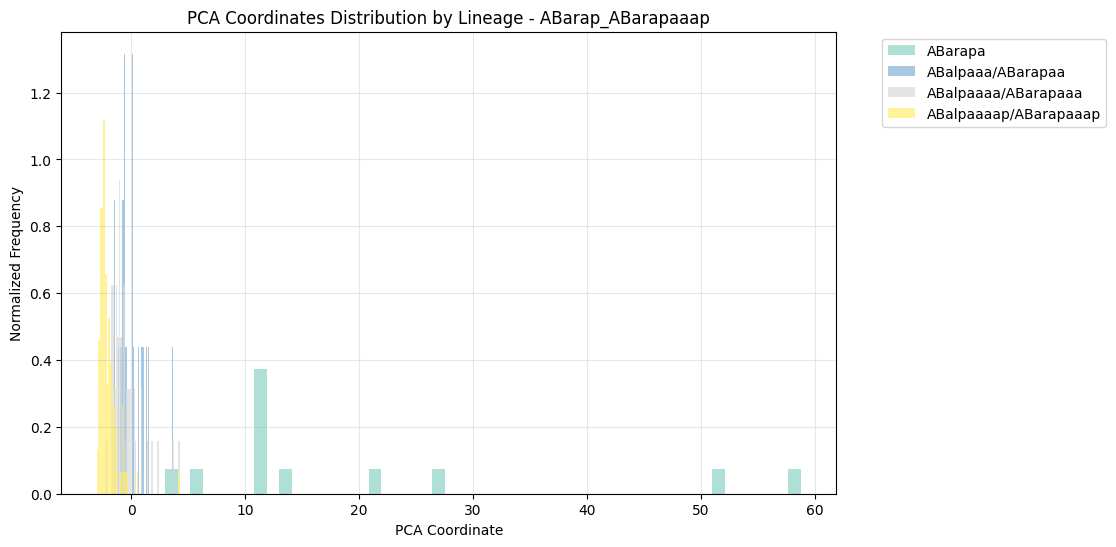

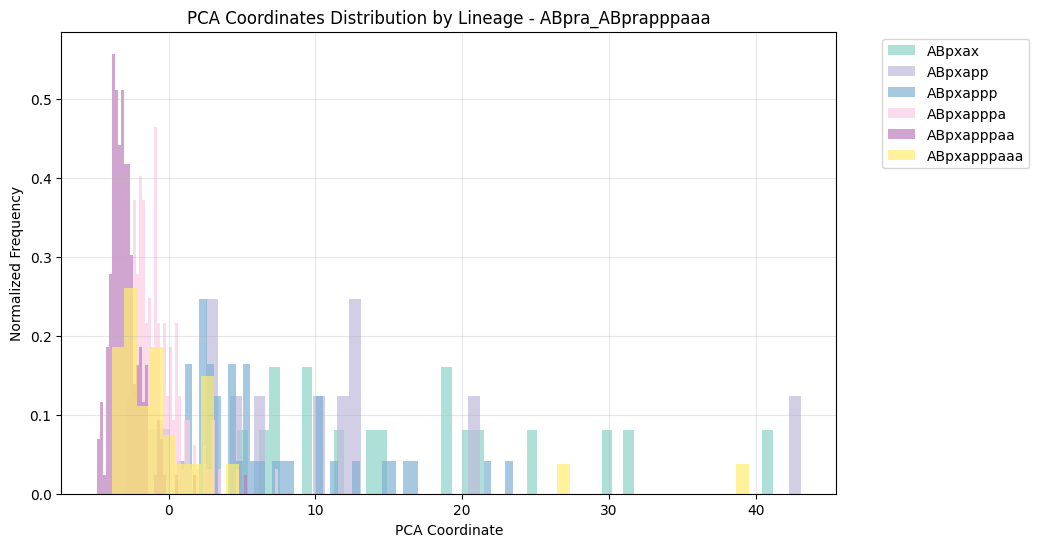

No PCA coordinates found in C_Caapaa


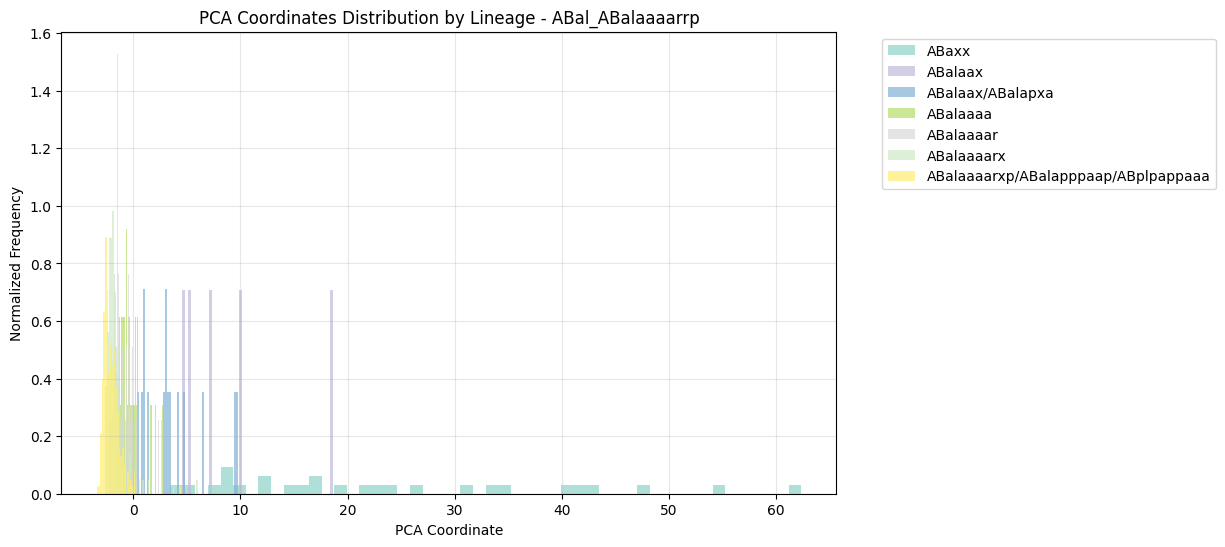

<Figure size 640x480 with 0 Axes>

In [63]:
# Set your base directory
base_dir = "/n/fs/ragr-data/users/viola/structuredVAE/data"

# Example 1: Plot a single path
fig = plot_single_path_histogram("MS_MSaapapaa", base_dir, method='pca')
plt.show()

# # Example 2: Get random paths and plot them
# random_paths = get_random_paths(base_dir, n_paths=20)
# fig = plot_multiple_paths_histograms(base_dir, random_paths, method='pca', n_cols=4)
# plt.show()

# # Example 3: Plot specific paths
# specific_paths = ["MS_MSaapapaa", "MS_MSaapapab", "MS_MSaapapac"]  # Add your path names
# fig = plot_multiple_paths_histograms(base_dir, specific_paths, method='umap', n_cols=3)
# plt.show()

# Example 4: Create both PCA and UMAP visualizations
random_paths = get_random_paths(base_dir,path_dict, n_paths=25)

# PCA visualization
fig_pca = plot_multiple_paths_histograms(base_dir, random_paths, method='pca', n_cols=5)
plt.suptitle('PCA Coordinates Distribution by Lineage', fontsize=16)
plt.show()

# # UMAP visualization  
# fig_umap = plot_multiple_paths_histograms(base_dir, random_paths, method='umap', n_cols=5)
# plt.suptitle('UMAP Coordinates Distribution by Lineage', fontsize=16)
# plt.show()

In [46]:
def check_available_coordinates(base_dir, n_check=10):
    """
    Check which paths have coordinates available.
    """
    loom_files = glob.glob(os.path.join(base_dir, "*.loom"))
    path_names = [os.path.basename(f).replace('.loom', '') for f in loom_files[:n_check]]
    
    print("Checking coordinate availability...")
    for path_name in path_names:
        try:
            loom_file = os.path.join(base_dir, f"{path_name}.loom")
            adata = anndata.read_loom(loom_file)
            
            has_pca = 'pca_1d' in adata.obs.columns
            has_umap = 'umap_1d' in adata.obs.columns
            has_lineage = 'lineage' in adata.obs.columns
            
            print(f"{path_name}: PCA={has_pca}, UMAP={has_umap}, Lineage={has_lineage}")
            
        except Exception as e:
            print(f"{path_name}: Error loading - {e}")

# Check what's available
check_available_coordinates(base_dir)

Checking coordinate availability...
ABalpa_ABalpaapppa3_1: PCA=False, UMAP=False, Lineage=True
ABpr_ABpraaaapad: PCA=True, UMAP=True, Lineage=True
AB_ABplpapaapa3_2: PCA=False, UMAP=False, Lineage=True
ABpr_ABprapaapa: PCA=True, UMAP=True, Lineage=True
ABp_ABpraapppa: PCA=True, UMAP=True, Lineage=True
ABaraaa1_ABaraapaaa: PCA=False, UMAP=False, Lineage=True
ABprp_ABplpppppa1: PCA=False, UMAP=False, Lineage=True
ABprapp_ABprapppappp: PCA=True, UMAP=True, Lineage=True
Cp_Cppaaap: PCA=True, UMAP=True, Lineage=True
MS_MSappppa: PCA=True, UMAP=True, Lineage=True


In [100]:
import scanpy as sc
import torch
from scipy.stats import entropy,spearmanr, kendalltau
base_dir = "/n/fs/ragr-data/users/viola/structuredVAE/data"
result_dir = "/n/fs/ragr-data/users/viola/structuredVAE/results/"
paths_dict_file = "/n/fs/ragr-data/users/viola/mouse_dev/scripts/new_c_elegans/paths_dict_tree.json.gz"
paths_dict = load_paths_dict(paths_dict_file)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
rows = []
cnt = 0
# for i, path in enumerate(sorted(paths_dict.keys())):
#     if i % 2 == 0:
#         adata = sc.read_h5ad(f"{base_dir}/scvi_path_{path}/trained.h5ad")
#         if not "Z_learned_nb" in adata.obsm.keys():
#             break
#         new_key = "lineage_category"
#         if 'lineage' in adata.obs.columns:
#             adata.obs[new_key] = adata.obs['lineage'].apply(
#                 lambda x: len(x.split("/")[0]) if "/" in x else len(x)
#             )
#         else:
#             print(f"Warning: No lineage column found in")
#         lineage_numeric = pd.to_numeric(adata.obs[new_key])
#         correlation, p_value = spearmanr(lineage_numeric, adata.obsm["Z_learned_nb"])
#         rows.append(correlation)
# print(len(rows))

In [73]:
abs_rho = [abs(rho) for rho in rows]

In [75]:
np.mean(abs_rho)

0.7107247325866612

In [101]:
def calculate_overlap_coefficient(
    embedding_1: np.ndarray,
    embedding_2: np.ndarray,
    grid_points: int = 1000
) -> float:
    """
    Calculates the Overlap Coefficient (OVL) between two 1D distributions
    using Kernel Density Estimation (KDE).

    OVL = ∫ min(f1(x), f2(x)) dx

    Args:
        embedding_1: 1D array of embedding values for the first group.
        embedding_2: 1D array of embedding values for the second group.
        grid_points: Number of points to use for numerical integration.

    Returns:
        The overlap coefficient (0 to 1). Returns np.nan if calculation fails.
    """
    # KDE requires at least 2 data points (and >1 unique values)
    if len(np.unique(embedding_1)) < 2 or len(np.unique(embedding_2)) < 2:
        return np.nan

    try:
        # 1. Create the KDEs
        kde1 = gaussian_kde(embedding_1)
        kde2 = gaussian_kde(embedding_2)

        # 2. Define the integration grid
        # Find the global min/max for the grid
        min_val = min(embedding_1.min(), embedding_2.min())
        max_val = max(embedding_1.max(), embedding_2.max())
        range_padding = (max_val - min_val) * 0.1 # Add 10% padding
        
        x_grid = np.linspace(
            min_val - range_padding,
            max_val + range_padding,
            grid_points
        )

        # 3. Evaluate KDEs on the grid
        pdf1 = kde1(x_grid)
        pdf2 = kde2(x_grid)

        # 4. Find the minimum (intersection)
        min_pdf = np.minimum(pdf1, pdf2)

        # 5. Integrate using the trapezoidal rule
        ovl = np.trapz(min_pdf, x_grid)

        return ovl

    except Exception as e:
        # Catch errors during KDE (e.g., singular matrix)
        print(f"Warning: Could not compute OVL. Error: {e}")
        return np.nan

# --- NEW: Main function to calculate both metrics for an AnnData object ---

def calculate_lineage_metrics(
    adata: sc.AnnData,
    obs_key: str,
    obsm_key: str
) -> (float, float):
    """
    Calculates Spearman's rho and the average OVL for a given AnnData object.

    Args:
        adata: The AnnData object.
        obs_key: The key in adata.obs for the categorical lineage nodes.
        obsm_key: The key in adata.obsm for the 1D embedding.

    Returns:
        A tuple (spearman_abs_rho, average_ovl)
    """
    lineage_numeric = pd.to_numeric(adata.obs[obs_key])
    embedding = adata.obsm[obsm_key].flatten()

    # 1. Calculate Spearman's Rank Correlation
    with warnings.catch_warnings():
        # Suppress Spearman's "ties" warning
        warnings.simplefilter("ignore")
        correlation, _ = spearmanr(lineage_numeric, embedding)
    spearman_abs_rho = abs(correlation)

    with warnings.catch_warnings():
        # Suppress Kendall's "ties" warning
        warnings.simplefilter("ignore")
        # variant='b' is the standard for handling ties
        kendall_corr, _ = kendalltau(lineage_numeric, embedding, variant='b')
    kendall_abs_tau = abs(kendall_corr)

    # 2. Calculate Average Overlap Coefficient (OVL)
    unique_nodes = np.unique(lineage_numeric)
    unique_nodes.sort()

    if len(unique_nodes) < 2:
        # OVL is not applicable if there's only one lineage category
        return spearman_abs_rho, np.nan

    ovl_scores = []
    for i in range(len(unique_nodes) - 1):
        node_1 = unique_nodes[i]
        node_2 = unique_nodes[i+1]

        # Get embedding values for each consecutive group
        emb_1 = embedding[lineage_numeric == node_1]
        emb_2 = embedding[lineage_numeric == node_2]

        ovl = calculate_overlap_coefficient(emb_1, emb_2)
        if not np.isnan(ovl):
            ovl_scores.append(ovl)

    if not ovl_scores:
        # Could not calculate any OVL scores
        average_ovl = np.nan
    else:
        average_ovl = np.mean(ovl_scores)

    return spearman_abs_rho, average_ovl, kendall_abs_tau

In [116]:
from scipy.stats import gaussian_kde
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

results_list = []

print(f"Starting analysis for {len(paths_dict.keys())} paths...")

for i, path in enumerate(sorted(paths_dict.keys())):
    # Processing every 2nd path, as in your original script
    if i % 2 == 0:
        adata_path = f"{base_dir}/scvi_path_{path}/trained.h5ad"
        
        if not os.path.exists(adata_path):
            print(f"Warning: File not found {adata_path}")
            continue

        try:
            adata = anndata.read_h5ad(adata_path)

            if "Z_learned_nb" not in adata.obsm.keys():
                print(f"Warning: 'Z_learned_nb' not in {adata_path}. Skipping.")
                break
            new_key = "lineage_category"
            if 'lineage' in adata.obs.columns:
                adata.obs[new_key] = adata.obs['lineage'].apply(
                    lambda x: len(x.split("/")[0]) if "/" in x else len(x)
                )
            else:
                print(f"Warning: No 'lineage' column in {adata_path}. Skipping.")
                continue
            
            # Calculate both metrics
            rho, ovl, kendall = calculate_lineage_metrics(
                adata,
                new_key,
                "Z_learned_nb"
            )
            # pca_rho, pca_ovl = calculate_lineage_metrics(adata,new_key,"pca")
            
            # print(f"Path {path}: Spearman |ρ| = {rho:.4f}, Avg. OVL = {ovl:.4f}")
            
            results_list.append({
                "path": path,
                "spearman_abs_rho": rho,
                "kendall_abs_tau": kendall,
                "average_ovl": ovl
            })

        except Exception as e:
            print(f"Error processing path {path}: {e}")
        if i%50==0:print(".",end="")

print("\n--- Analysis Complete ---")

# Convert final results to a DataFrame for easy viewing
if results_list:
    results_df = pd.DataFrame(results_list)
    print(results_df)
    
    # You can save this to a file
    # output_file = os.path.join(result_dir, "lineage_metrics.csv")
    # results_df.to_csv(output_file, index=False)
    # print(f"Results saved to {output_file}")
else:
    print("No results were generated.")

Using device: cpu
Starting analysis for 1828 paths...
..................................Error processing path P0_Z3: not enough values to unpack (expected 3, got 2)

--- Analysis Complete ---
               path  spearman_abs_rho  kendall_abs_tau  average_ovl
0    ABa_ABalaaaalp          0.311665         0.344135     0.306599
1    ABa_ABalaaappl          0.578037         0.467937     0.534040
2    ABa_ABalpaaaaa          0.626523         0.499889     0.490179
3    ABa_ABalpaaapa          0.920071         0.789247     0.408321
4    ABa_ABalpappaa          0.837739         0.709097     0.466154
..              ...               ...              ...          ...
842        P0_Earpp          0.342484         0.271558     0.313401
843        P0_Eplap          0.699586         0.563199     0.471268
844        P0_Eplpp          0.481633         0.385656     0.615374
845        P0_Eprap          0.238042         0.192020     0.445096
846        P0_Eprpp          0.489839         0.397680     0

In [117]:
results_df.spearman_abs_rho.mean()

0.7124226943026156

In [118]:
results_df.kendall_abs_tau.mean()

0.6024553975331035

In [119]:
results_df.average_ovl.mean()

0.4422345641392675

Text(0, 0.5, 'average overlap coeff')

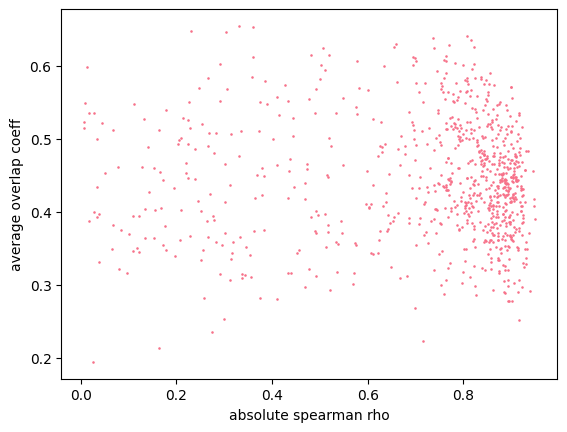

In [120]:
plt.scatter(results_df.spearman_abs_rho, results_df.average_ovl, s=0.7)
plt.xlabel("absolute spearman rho")
plt.ylabel("average overlap coeff")

Text(0, 0.5, 'average spearman rho')

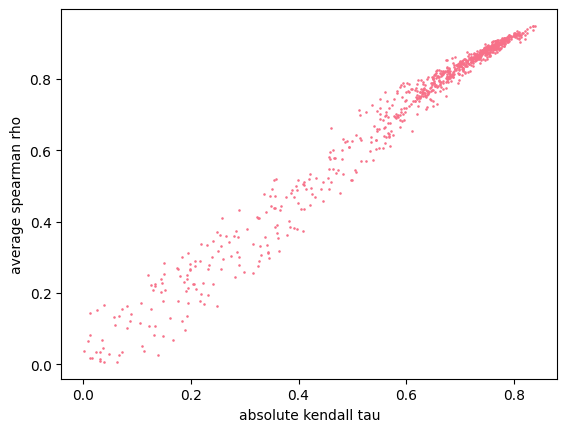

In [121]:
plt.scatter(results_df.kendall_abs_tau, results_df.spearman_abs_rho, s=0.7)
plt.xlabel("absolute kendall tau")
plt.ylabel("average spearman rho")

In [98]:
coeff, pval = spearmanr(results_df.spearman_abs_rho,results_df.average_ovl)
print(coeff)

-0.11399096782685864


In [122]:
from scipy.stats import gaussian_kde
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

results_list = []

print(f"Starting analysis for {len(paths_dict.keys())} paths...")
key_learned = "Z_learned_log_norm_gauss"
for i, path in enumerate(sorted(paths_dict.keys())):
    # Processing every 2nd path, as in your original script
    if i % 2 == 1:
        adata_path = f"{base_dir}/scvi_path_{path}/trained.h5ad"
        
        if not os.path.exists(adata_path):
            print(f"Warning: File not found {adata_path}")
            continue

        try:
            adata = anndata.read_h5ad(adata_path)

            if key_learned not in adata.obsm.keys():
                print(f"Warning: {key_learned} not in {adata_path}. Skipping.")
                break
            new_key = "lineage_category"
            if 'lineage' in adata.obs.columns:
                adata.obs[new_key] = adata.obs['lineage'].apply(
                    lambda x: len(x.split("/")[0]) if "/" in x else len(x)
                )
            else:
                print(f"Warning: No 'lineage' column in {adata_path}. Skipping.")
                continue
            
            # Calculate both metrics
            rho, ovl, kendall = calculate_lineage_metrics(
                adata,
                new_key,
                key_learned
            )
            # pca_rho, pca_ovl = calculate_lineage_metrics(adata,new_key,"pca")
            
            # print(f"Path {path}: Spearman |ρ| = {rho:.4f}, Avg. OVL = {ovl:.4f}")
            
            results_list.append({
                "path": path,
                "spearman_abs_rho": rho,
                "kendall_abs_tau": kendall,
                "average_ovl": ovl
            })

        except Exception as e:
            print(f"Error processing path {path}: {e}")
        if i%50==0:print(".",end="")

print("\n--- Analysis Complete ---")

# Convert final results to a DataFrame for easy viewing
if results_list:
    results_df = pd.DataFrame(results_list)
    print(results_df)
    
    # You can save this to a file
    # output_file = os.path.join(result_dir, "lineage_metrics.csv")
    # results_df.to_csv(output_file, index=False)
    # print(f"Results saved to {output_file}")
else:
    print("No results were generated.")

Using device: cpu
Starting analysis for 1828 paths...
Error processing path P0_Z2: not enough values to unpack (expected 3, got 2)
Error processing path P1_Z2: not enough values to unpack (expected 3, got 2)

--- Analysis Complete ---
               path  spearman_abs_rho  kendall_abs_tau  average_ovl
0    ABa_ABalaaapar          0.663377         0.528079     0.352236
1    ABa_ABalaapaap          0.236801         0.172441     0.406772
2    ABa_ABalpaaaap          0.854454         0.697897     0.183241
3    ABa_ABalpaaapp          0.888826         0.738729     0.370038
4    ABa_ABalpapppa          0.776852         0.575592     0.468610
..              ...               ...              ...          ...
863        P1_Earpp          0.661088         0.528574     0.302171
864        P1_Eplap          0.692973         0.555878     0.179575
865        P1_Eplpp          0.606680         0.481846     0.498384
866        P1_Eprap          0.419656         0.332300     0.448886
867        P1_Epr

In [123]:
results_df.spearman_abs_rho.mean()

0.46139951291957515

In [124]:
results_df.kendall_abs_tau.mean()

0.33689795403181216

In [125]:
results_df.average_ovl.mean()

0.493216078624652